# Aufgabe 5
## Bestimmung der Werte für Verdampfungswärme mit Fit
Für Aufgabe 5 sollen für aus den Messwerten die Verdampfungswärme, mittels der Clausius-Clapeyron-Gleichung, ermitteln. DIese lautet wie folgt:
$$\frac{d p_s}{dT} = \frac{Q_{23}}{T \cdot \Delta V_m}$$
Dabei ist $V_m$ der Unterschied des Volumens an der Maxwell-Geraden. Als erstes müssen wir also $p_s$ und $T$ als plot darstellen um daraus $\frac{dp_s}{dT}$ zu bekommen. Mithile der Formel und der Umstellung von $V_m = \frac{1}{n}(V_G-V_F)$ können wir dann die Verdampfungswärme berechnen.
$$Q_{23}(T) = \frac{(V_G - V_F)}{n}T\frac{dp_s}{dT}$$
$V_G$ und $V_F$ wurden dabei händisch aus den Plots in Aufgabe 2 entnommen. $n$ ist die Stoffmenge, die in Aufgabe 3 bestimmt wurde.

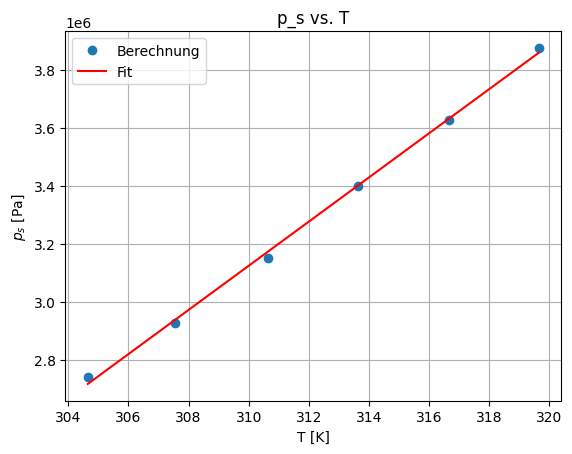

Q für T=304.65 K: 10179.64 J/mol
Q für T=307.55 K: 8408.08 J/mol
Q für T=310.65 K: 6605.53 J/mol
Q für T=313.65 K: 4763.80 J/mol
Q für T=316.65 K: 2885.62 J/mol
Q für T=319.65 K: 970.99 J/mol


In [ ]:
# | fig-cap: Sättigungsdruck gegen Temperatur
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit

#Konstante
n = 0.001253 # in mol
a = 0.79 
b = 0.88*1e-4
R = 8.314 # J/(mol*K)
Q_23 = []
T_k = ((8 * a)/(27*R*b))

def Q_theo(Q_0, T):
    return Q_0 * (1 - T/T_k) ** (3/8)

# Gegebene Messwerte
T = np.array([304.65, 307.55, 310.65, 313.65, 316.65, 319.65])  # in K
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])  # in Pa
v_g = np.array([0.9, 0.8, 0.7, 0.6, 0.5, 0.4])  # in m^3/mol
v_f = np.array([0.35, 0.35, 0.35, 0.35, 0.35, 0.35])  # in m^3/mol
v_g = v_g * 1e-6
v_f = v_f * 1e-6
fit_p_s = np.polyfit(T, p_s, 1)
T_T_k = T / T_k

#  Steigung der Geraden
slope = fit_p_s[0]
# y-Achsenabschnitt der Geraden
intercept = fit_p_s[1]

# Plot
plt.plot(T, p_s, 'o', label='Berechnung')
plt.plot(T, np.polyval(fit_p_s, T), 'r-', label='Fit')
plt.xlabel('T [K]')
plt.ylabel(r'$p_s$ [Pa]')
plt.legend()
plt.title('$p_s$ gegen $T$')
plt.grid(True)
plt.show()

# Verdampufngswärme berechnen
for i in range(len(T)):
    Q = ((v_g[i] - v_f[i]) * T[i] * slope)/n
    Q_23.append(Q)
    print(f"Q für T={T[i]} K: {Q:.2f} J/mol")

fit_q_23 = np.polyfit(T_T_k, Q_23, 1)
# Curve Fit für Q_theo
def Q_theo_func(T_T_k, Q_0):
    return Q_0 * (1 - T_T_k) ** (3/8)

popt, pcov = curve_fit(Q_theo_func, T_T_k, Q_23, p0=[10000])
Q_0_fit = popt[0]
Q_theo_fit = Q_theo_func(T_T_k, Q_0_fit)

# Plot der theoretischen Kurve
#plt.plot(T/T_k, Q_theo_fit, 'g--', label='Q_theo Fit')





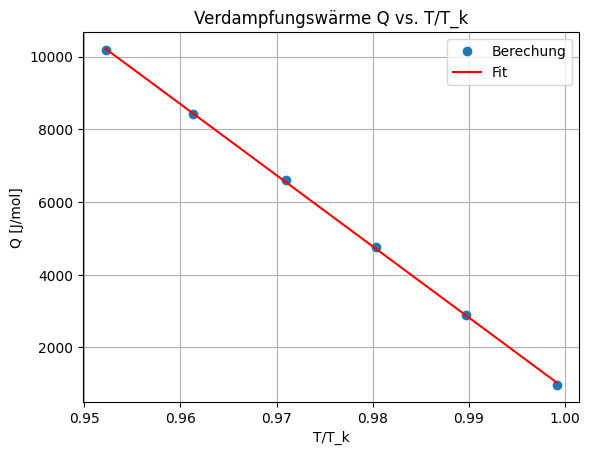

In [9]:
# | fig-cap: Verdampfungswärme Q vs. T/T_k mit Fit
# Plott der Verdampfungswärme zu T/Tk
plt.plot(T/T_k, Q_23, 'o', label='Berechung')
plt.plot(T/T_k, np.polyval(fit_q_23, T/T_k), 'r-', label='Fit')
plt.xlabel('T/T_k')
plt.ylabel('Q [J/mol]')
plt.legend()
plt.title('Verdampfungswärme Q vs. T/T_k')
plt.grid(True)
plt.show()

Für den zweiten Teil der Aufgabe haben wir die Verdampfungswärme Q im Vergleich zu $\frac{T}{T_k}$ angeschaut. $T_k$ ist die kritische Temperatur und wurde berechnet mithilfe der Formel:
$$T_k = \frac{8a}{27R b}$$
und für $SF_6$ sind die Konstanten: $a = a=0.79 N m^4 mol^{-2}$ und $b = 0.88\cdot 10^{-4} m^3 mol^{-1}$.

Je näher die Temperatur an der Kritischen ist, also je näher das Verhältnis an 1 ist, desto Temperaturabhängiger sollte die Verdampfungswärme sein. In unserem Fall war der Fit linear, wir glauben das liegt zum einen daran, dass wir sehr nahe an der kritischen Temperatur sind. Vor allem aber liegt es an den zu ungenauen Messmöglichkeiten. Die einzigen Variablen die die Formel hatte, waren die Volumina und die Temperatur. Die Temperatur haben wir immer in den gleichen Abständen gemessen und da das Volumen auch nur in 0,1 und 0,05ml Abständen gemessen wurde, kam dort bei unseren Messwerten ein lineares Verhältnis. Unsere Maxwell-Gerade ging immer bis 0,35ml und hat immer in 0,1 Abständen angefangen, für alle 3°C die wir geändert haben und daher kommt der lineare fit. Da der Fit jetzt überall linear ist, können wir nicht den korrekten y-Achsenabschnitt ablesen und somit nicht Q(0) bestimmen, mithilfe dessen wir näherungsweise an der kritischen Temperatur die Verdampfungswärme hätten berechnen können. Dafür müssen wir versuchen, einen möglichst ähnlichen anderen fit zu finden.

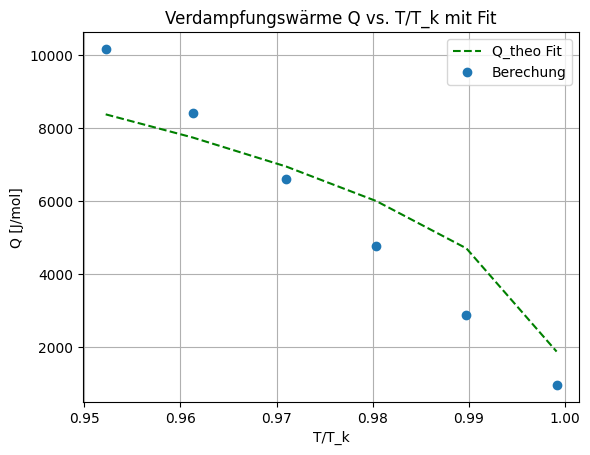

Q_0_fit = 26223.77 ± 2329.45 J/mol


In [6]:
# | fig-cap: Verdampfungswärme Q vs. T/T_k mit Fit zum ermitteln vom theoretischen Q_{23}(0)
plt.plot(T/T_k, Q_theo_fit, 'g--', label='Q_theo Fit')

# Plott der Verdampfungswärme zu T/Tk
plt.plot(T/T_k, Q_23, 'o', label='Berechung')
#plt.plot(T/T_k, np.polyval(fit_q_23, T/T_k), 'r-', label='Fit')
plt.xlabel('T/T_k')
plt.ylabel('Q [J/mol]')
plt.legend()
plt.title('Verdampfungswärme Q vs. T/T_k mit Fit')
plt.grid(True)
plt.show()
# Schreibe hier die Abweichung von Q_0_fit als Fehler (Standardabweichung aus pcov)
Q_0_err = np.sqrt(pcov[0, 0])
print(f"Q_0_fit = {Q_0_fit:.2f} ± {Q_0_err:.2f} J/mol")

Zum Schluss, wurde trotz der eher linearen Abhängig, nochmal ein Fit durchgeführt mit der näherungweise bestimmten Formel aus der Versuchsanleitung:
$$Q_{23}(T) = Q(0) \left(1 - \frac{T}{T_k}\right)^(3/8)$$
Dabei kamen wir für den Fit Parameter $Q_{23} = Q(0)$ auf $$26.22 \pm 23.29$ kJ/mol, wobei man eine sehr hohe Abweichung feststellt. Dies wird aber im folgenden sowie im vorherigen Abschnitt genauer diskutiert.

Wenn man die gemittelte molare Verdampfungswärme $Q_{23}$ mit der aus Aufgabe 3 vergleicht, fällt auf das diese sich ziemlich stark unterscheiden. Dieser entsteht durch die große Unsicherheiten was sich wohl auf die vielen Fehlereinflüsse und insbesondere auf das manuelle Ablesen der Volumina $V_F$ und $V_G$ aus den Plots in Aufgabe 2 zurückführen lässt, sowie das Ablösen der Messwerte an den Messgeräten beim Experiment, wobei auch immer eine Usicherheit von $\pm 0.25 \cdot 10^5 \, \mathrm{Pa}$ bzw. $\pm 0.025$ml besteht.
Ein anderer Messfehler könnte sein, Temperaturschwankungen die nicht berücksichtigt wurden, da es kein perfekt abgeschlossenens System und es somit auch keine perfekte isothermer Prozess ist. Wir reden hier zwar von, verhältnismäßig sehr kleinen Temperaturschwankungen, jedoch zeigt sich auch hier, dass die latente Wärme stark temperaturabhängig.